In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use('pgf.mplstyle')
plt.rcParams.update({
    "pgf.preamble": "\n".join([
        r"\usepackage{newpxmath}",
        r"\usepackage{newpxtext}",
    ]),
})

from qpotts import PottsModel, Start

FIG_PATH = '../results/'


In [5]:
L=100
T=3
q=2

num_samples = 50_000
step = 100
xs = range(0,num_samples, step)

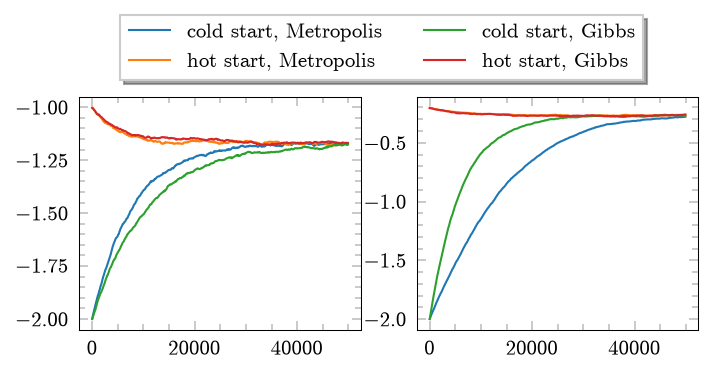

In [8]:
def plot_convergence(L, T, q, ax) -> None:
    pm = PottsModel(L, T, q, Start.Cold)
    energies = pm.sample_metropolis(num_samples)
    ax.plot(xs, energies[::step], label="cold start, Metropolis")

    # hot start, Metropolis
    pm = PottsModel(L, T, q, Start.Hot)
    energies = pm.sample_metropolis(num_samples)
    ax.plot(xs, energies[::step], label="hot start, Metropolis")

    # cold start, Gibbs
    pm = PottsModel(L, T, q, Start.Cold)
    energies = pm.sample_gibbs(num_samples)
    ax.plot(xs, energies[::step], label="cold start, Gibbs")

    # hot start, Gibbs
    pm = PottsModel(L, T, q, Start.Hot)
    energies = pm.sample_gibbs(num_samples)
    ax.plot(xs, energies[::step], label="hot start, Gibbs")

fig, ax = plt.subplots(1, 2, figsize=(5,2), dpi=150)

plot_convergence(L, T, q=2, ax=ax[0])
plot_convergence(L, T, q=10, ax=ax[1])

ax[0].legend(loc='upper center', bbox_to_anchor=(1.075, 1.4),
                     ncol=2, fancybox=False, shadow=True)

plt.savefig(FIG_PATH + "convergence.pdf", bbox_inches='tight', backend='pgf')
plt.show()